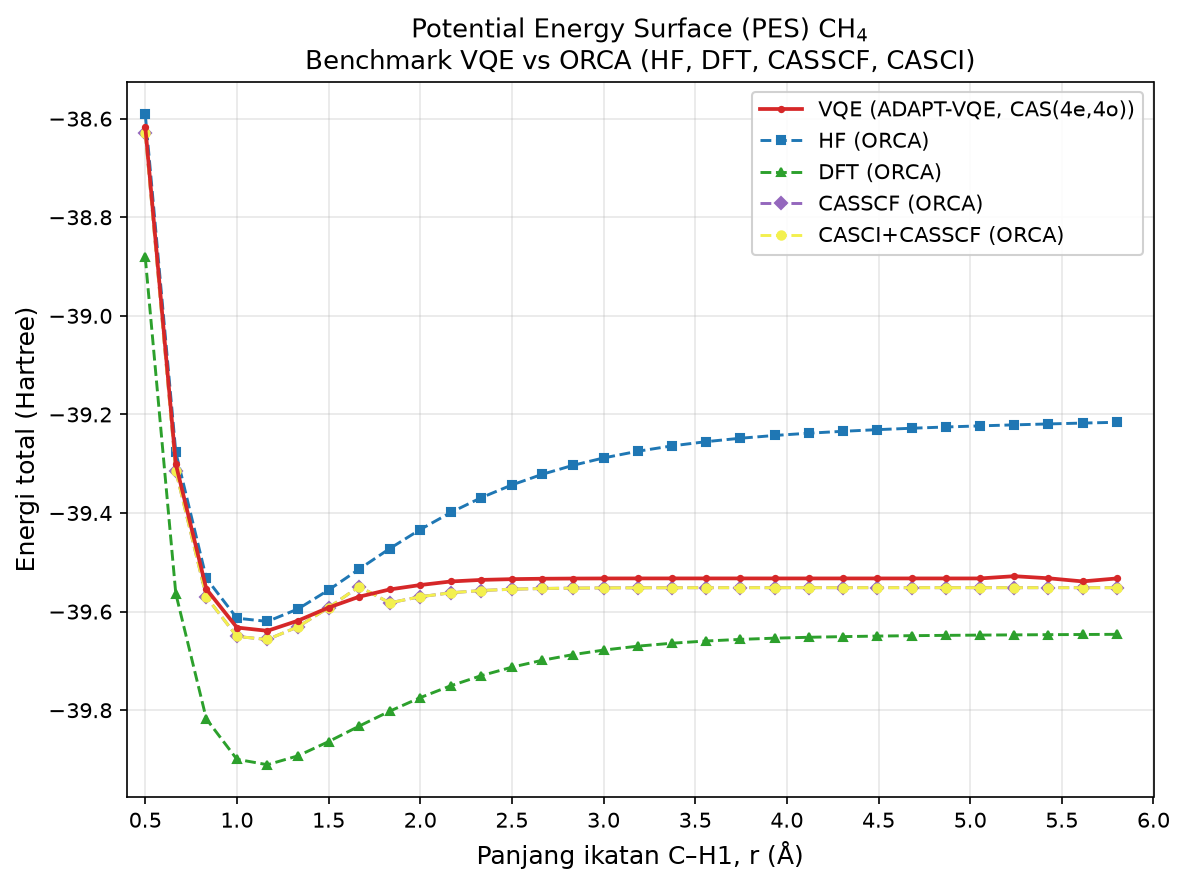

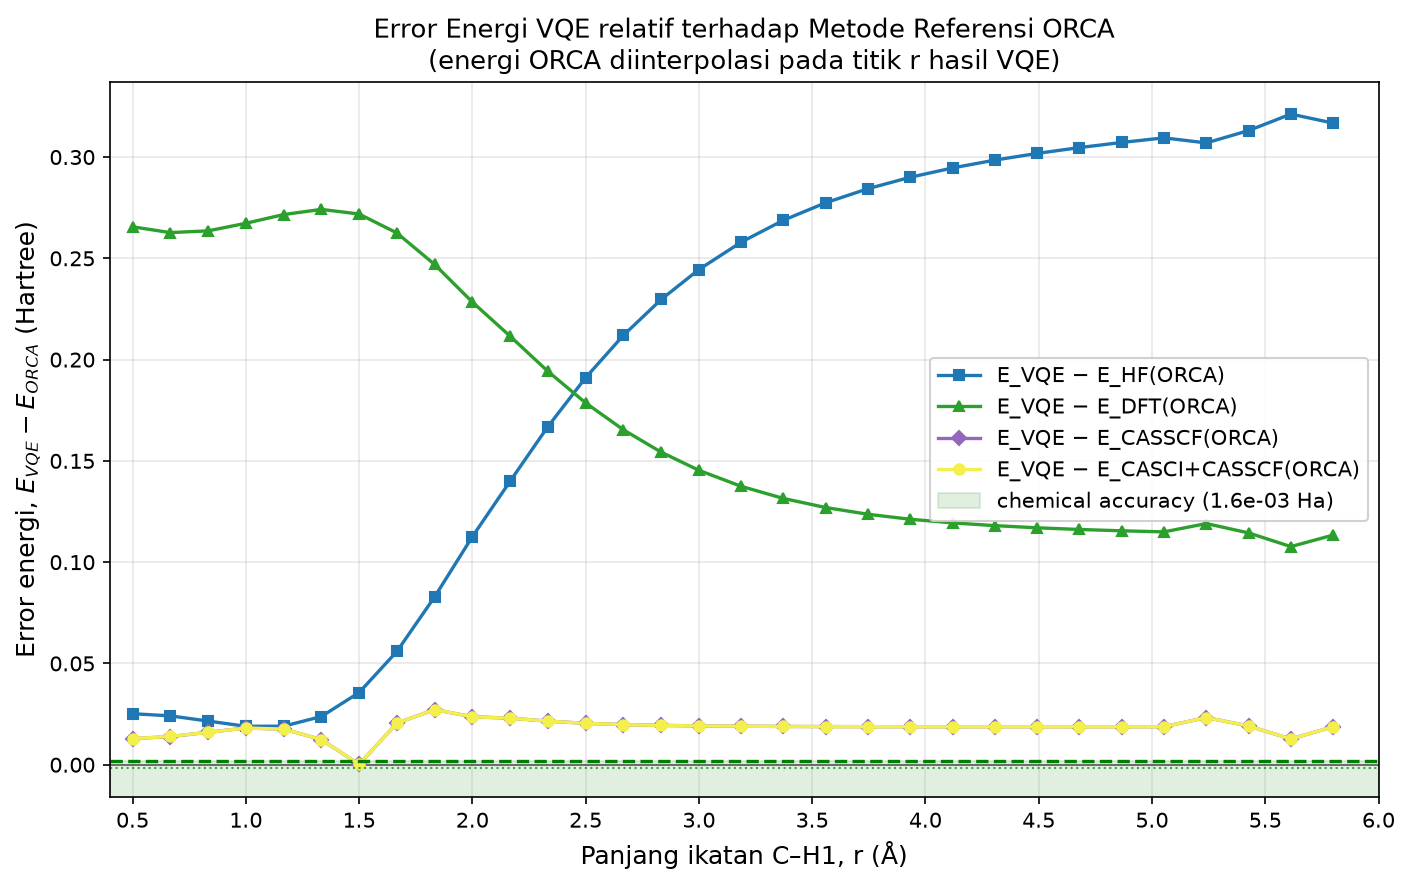

  r(Å)          ΔHF         ΔDFT      ΔCASSCF ΔCASCI CASSCF
  0.50   2.5182e-02   2.6555e-01   1.2884e-02   1.2884e-02
  0.67   2.4113e-02   2.6270e-01   1.3893e-02   1.3975e-02
  0.83   2.1551e-02   2.6356e-01   1.6016e-02   1.5987e-02
  1.00   1.8973e-02   2.6730e-01   1.8104e-02   1.8104e-02
  1.17   1.9024e-02   2.7160e-01   1.7594e-02   1.7591e-02
  1.33   2.3784e-02   2.7415e-01   1.2409e-02   1.2416e-02
  1.50   3.5631e-02   2.7187e-01   1.5135e-04   1.5135e-04
  1.67   5.5903e-02   2.6252e-01   2.0526e-02   2.0534e-02
  1.83   8.2850e-02   2.4697e-01   2.7219e-02   2.7222e-02
  2.00   1.1259e-01   2.2841e-01   2.3654e-02   2.3654e-02
  2.17   1.3996e-01   2.1155e-01   2.2980e-02   2.2979e-02
  2.33   1.6691e-01   1.9420e-01   2.1502e-02   2.1502e-02
  2.50   1.9109e-01   1.7863e-01   2.0440e-02   2.0440e-02
  2.67   2.1197e-01   1.6535e-01   1.9802e-02   1.9802e-02
  2.83   2.2967e-01   1.5431e-01   1.9410e-02   1.9410e-02
  3.00   2.4446e-01   1.4534e-01   1.9162e-02   1.9162e

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# ----------------------------------------------------------------------
# 1. DATA (hasil ekstraksi dari file .out)
# ----------------------------------------------------------------------
data_evqe = [
    {"r": 0.50000, "vqe": -38.61593592},
    {"r": 0.66667, "vqe": -39.30077880},
    {"r": 0.83333, "vqe": -39.55416880},
    {"r": 1.00000, "vqe": -39.63228249},
    {"r": 1.16667, "vqe": -39.63895900},
    {"r": 1.33333, "vqe": -39.61836770},
    {"r": 1.50000, "vqe": -39.59180648},
    {"r": 1.66667, "vqe": -39.56976110},
    {"r": 1.83333, "vqe": -39.55503613},
    {"r": 2.00000, "vqe": -39.54606788},
    {"r": 2.16667, "vqe": -39.53883572},
    {"r": 2.33333, "vqe": -39.53566118},
    {"r": 2.50000, "vqe": -39.53409833},
    {"r": 2.66667, "vqe": -39.53328922},
    {"r": 2.83333, "vqe": -39.53289499},
    {"r": 3.00000, "vqe": -39.53272028},
    {"r": 3.18700, "vqe": -39.53265124},
    {"r": 3.37300, "vqe": -39.53263989},
    {"r": 3.56000, "vqe": -39.53264727},
    {"r": 3.74700, "vqe": -39.53265783},
    {"r": 3.93300, "vqe": -39.53268476},
    {"r": 4.12000, "vqe": -39.53267189},
    {"r": 4.30700, "vqe": -39.53267525},
    {"r": 4.49300, "vqe": -39.53267521},
    {"r": 4.68000, "vqe": -39.53267807},
    {"r": 4.86700, "vqe": -39.53267623},
    {"r": 5.05300, "vqe": -39.53267869},
    {"r": 5.24000, "vqe": -39.52812699},
    {"r": 5.42700, "vqe": -39.53234359},
    {"r": 5.61300, "vqe": -39.53872721},
    {"r": 5.80000, "vqe": -39.53267753},
]

# ORCA HF: r (Å), E_HF (Ha)
data_hf = [
    {"r": 0.50000, "hf": -38.59075348},
    {"r": 0.66667, "hf": -39.27666606},
    {"r": 0.83333, "hf": -39.53261736},
    {"r": 1.00000, "hf": -39.61330956},
    {"r": 1.16667, "hf": -39.61993461},
    {"r": 1.33333, "hf": -39.59458328},
    {"r": 1.50000, "hf": -39.55617520},
    {"r": 1.66667, "hf": -39.51385760},
    {"r": 1.83333, "hf": -39.47218601},
    {"r": 2.00000, "hf": -39.43348267},
    {"r": 2.16667, "hf": -39.39887686},
    {"r": 2.33333, "hf": -39.36875058},
    {"r": 2.50000, "hf": -39.34301240},
    {"r": 2.66667, "hf": -39.32131672},
    {"r": 2.83333, "hf": -39.30322030},
    {"r": 3.00000, "hf": -39.28825847},
    {"r": 3.18667, "hf": -39.27466511},
    {"r": 3.37333, "hf": -39.26382946},
    {"r": 3.56000, "hf": -39.25519354},
    {"r": 3.74667, "hf": -39.24827175},
    {"r": 3.93333, "hf": -39.24266100},
    {"r": 4.12000, "hf": -39.23804546},
    {"r": 4.30667, "hf": -39.23417799},
    {"r": 4.49333, "hf": -39.23087710},
    {"r": 4.68000, "hf": -39.22800881},
    {"r": 4.86667, "hf": -39.22547661},
    {"r": 5.05333, "hf": -39.22320762},
    {"r": 5.24000, "hf": -39.22115019},
    {"r": 5.42667, "hf": -39.21926619},
    {"r": 5.61333, "hf": -39.21752801},
    {"r": 5.80000, "hf": -39.21591448},
]

# ORCA DFT (B3LYP): r (Å), E_DFT (Ha)
data_dft = [
    {"r": 0.50000, "dft": -38.88148507},
    {"r": 0.66667, "dft": -39.56348053},
    {"r": 0.83333, "dft": -39.81772520},
    {"r": 1.00000, "dft": -39.89958029},
    {"r": 1.16667, "dft": -39.91056210},
    {"r": 1.33333, "dft": -39.89251948},
    {"r": 1.50000, "dft": -39.86368097},
    {"r": 1.66667, "dft": -39.83228370},
    {"r": 1.83333, "dft": -39.80200409},
    {"r": 2.00000, "dft": -39.77447741},
    {"r": 2.16667, "dft": -39.75038396},
    {"r": 2.33333, "dft": -39.72986141},
    {"r": 2.50000, "dft": -39.71272750},
    {"r": 2.66667, "dft": -39.69863654},
    {"r": 2.83333, "dft": -39.68720774},
    {"r": 3.00000, "dft": -39.67806002},
    {"r": 3.18667, "dft": -39.67008848},
    {"r": 3.37333, "dft": -39.66408467},
    {"r": 3.56000, "dft": -39.65960857},
    {"r": 3.74667, "dft": -39.65629333},
    {"r": 3.93333, "dft": -39.65386127},
    {"r": 4.12000, "dft": -39.65206532},
    {"r": 4.30667, "dft": -39.65069900},
    {"r": 4.49333, "dft": -39.64963915},
    {"r": 4.68000, "dft": -39.64881200},
    {"r": 4.86667, "dft": -39.64815822},
    {"r": 5.05333, "dft": -39.64762901},
    {"r": 5.24000, "dft": -39.64717835},
    {"r": 5.42667, "dft": -39.64677380},
    {"r": 5.61333, "dft": -39.64640265},
    {"r": 5.80000, "dft": -39.64606134},
]

# ORCA CASSCF (SlowConv, CAS(4,4)): r (Å), E_CASSCF (Ha)
data_casscf = [
    {"r": 0.50000, "casscf": -38.62882028},
    {"r": 0.66667, "casscf": -39.31467229},
    {"r": 0.83333, "casscf": -39.57018472},
    {"r": 1.00000, "casscf": -39.65038609},
    {"r": 1.16667, "casscf": -39.65655316},
    {"r": 1.33333, "casscf": -39.63077648},
    {"r": 1.50000, "casscf": -39.59195783},
    {"r": 1.66667, "casscf": -39.54923556},
    {"r": 1.83333, "casscf": -39.58225554},
    {"r": 2.00000, "casscf": -39.56972154},
    {"r": 2.16667, "casscf": -39.56181558},
    {"r": 2.33333, "casscf": -39.55716288},
    {"r": 2.50000, "casscf": -39.55453844},
    {"r": 2.66667, "casscf": -39.55309170},
    {"r": 2.83333, "casscf": -39.55230494},
    {"r": 3.00000, "casscf": -39.55188243},
    {"r": 3.18667, "casscf": -39.55165502},
    {"r": 3.37333, "casscf": -39.55153119},
    {"r": 3.56000, "casscf": -39.55147372},
    {"r": 3.74667, "casscf": -39.55144764},
    {"r": 3.93333, "casscf": -39.55143619},
    {"r": 4.12000, "casscf": -39.55143132},
    {"r": 4.30667, "casscf": -39.55142931},
    {"r": 4.49333, "casscf": -39.55142836},
    {"r": 4.68000, "casscf": -39.55142816},
    {"r": 4.86667, "casscf": -39.55142800},
    {"r": 5.05333, "casscf": -39.55142792},
    {"r": 5.24000, "casscf": -39.55142788},
    {"r": 5.42667, "casscf": -39.55142786},
    {"r": 5.61333, "casscf": -39.55142784},
    {"r": 5.80000, "casscf": -39.55142784},
]

# ORCA CASCI (CAS(4,4), orbital HF): r (Å), E_CASCI (Ha)
data_casci_hf = [
    {"r": 0.50000, "casci_hf": -38.45486695},
    {"r": 0.66667, "casci_hf": -39.01932459},
    {"r": 0.83333, "casci_hf": -39.14112384},
    {"r": 1.00000, "casci_hf": -39.08753170},
    {"r": 1.16667, "casci_hf": -38.96978991},
    {"r": 1.33333, "casci_hf": -38.83619135},
    {"r": 1.50000, "casci_hf": -38.70789627},
    {"r": 1.66667, "casci_hf": -38.59333995},
    {"r": 1.83333, "casci_hf": -38.49483185},
    {"r": 2.00000, "casci_hf": -38.41206082},
    {"r": 2.16667, "casci_hf": -38.34371370},
    {"r": 2.33333, "casci_hf": -38.28808180},
    {"r": 2.50000, "casci_hf": -38.24332204},
    {"r": 2.66667, "casci_hf": -38.20763625},
    {"r": 2.83333, "casci_hf": -38.17939069},
    {"r": 3.00000, "casci_hf": -38.15716379},
]

# ORCA CASCI (CAS(4,4), orbital casscf): r (Å), E_CASCI (Ha)
data_casci_casscf = [
    {"r": 0.50000, "casci_casscf": -38.62882028},
    {"r": 0.66667, "casci_casscf": -39.31475362},
    {"r": 0.83333, "casci_casscf": -39.57015614},
    {"r": 1.00000, "casci_casscf": -39.65038609},
    {"r": 1.16667, "casci_casscf": -39.65655031},
    {"r": 1.33333, "casci_casscf": -39.63078336},
    {"r": 1.50000, "casci_casscf": -39.59195783},
    {"r": 1.66667, "casci_casscf": -39.54922697},
    {"r": 1.83333, "casci_casscf": -39.58225858},
    {"r": 2.00000, "casci_casscf": -39.56972154},
    {"r": 2.16667, "casci_casscf": -39.56181437},
    {"r": 2.33333, "casci_casscf": -39.55716357},
    {"r": 2.50000, "casci_casscf": -39.55453844},
    {"r": 2.66667, "casci_casscf": -39.55309149},
    {"r": 2.83333, "casci_casscf": -39.55230505},
    {"r": 3.00000, "casci_casscf": -39.55188243},
    {"r": 3.18667, "casci_casscf": -39.55165499},
    {"r": 3.37333, "casci_casscf": -39.55153120},
    {"r": 3.56000, "casci_casscf": -39.55147372},
    {"r": 3.74667, "casci_casscf": -39.55144764},
    {"r": 3.93333, "casci_casscf": -39.55143619},
    {"r": 4.12000, "casci_casscf": -39.55143132},
    {"r": 4.30667, "casci_casscf": -39.55142931},
    {"r": 4.49333, "casci_casscf": -39.55142836},
    {"r": 4.68000, "casci_casscf": -39.55142816},
    {"r": 4.86667, "casci_casscf": -39.55142800},
    {"r": 5.05333, "casci_casscf": -39.55142792},
    {"r": 5.24000, "casci_casscf": -39.55142788},
    {"r": 5.42667, "casci_casscf": -39.55142786},
    {"r": 5.61333, "casci_casscf": -39.55142784},
    {"r": 5.80000, "casci_casscf": -39.55142784},
]

# ----------------------------------------------------------------------
# 2. KONVERSI KE ARRAY NUMPY
# ----------------------------------------------------------------------

r_vqe = np.array([d["r"] for d in data_evqe])
e_vqe = np.array([d["vqe"] for d in data_evqe])

r_hf = np.array([d["r"] for d in data_hf]);         e_hf_orca = np.array([d["hf"] for d in data_hf])
r_dft = np.array([d["r"] for d in data_dft]);       e_dft_orca = np.array([d["dft"] for d in data_dft])
r_casscf = np.array([d["r"] for d in data_casscf]); e_casscf_orca = np.array([d["casscf"] for d in data_casscf])
r_casci_hf = np.array([d["r"] for d in data_casci_hf]);   e_casci_hf_orca = np.array([d["casci_hf"] for d in data_casci_hf])
r_casci_casscf = np.array([d["r"] for d in data_casci_casscf]); e_casci_casscf_orca = np.array([d["casci_casscf"] for d in data_casci_casscf])

# ----------------------------------------------------------------------
# 3. PLOT PES (semua metode pada sumbu r masing-masing)
# ----------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

ax.plot(r_vqe, e_vqe, marker=".", ms=5, lw=1.8, color="#d62728",
         label="VQE (ADAPT-VQE, CAS(4e,4o))", zorder=5)
ax.plot(r_hf, e_hf_orca, marker="s", ms=4, lw=1.4, ls="--", color="#1f77b4",
         label="HF (ORCA)")
ax.plot(r_dft, e_dft_orca, marker="^", ms=4, lw=1.4, ls="--", color="#2ca02c",
         label="DFT (ORCA)")
ax.plot(r_casscf, e_casscf_orca, marker="D", ms=4, lw=1.4, ls="--", color="#9467bd",
         label="CASSCF (ORCA)")
#ax.plot(r_casci_hf, e_casci_hf_orca, marker="v", ms=4, lw=1.4, ls="--", color="#ff7f0e",
#         label="CASCI (ORCA)")
ax.plot(r_casci_casscf, e_casci_casscf_orca, marker="o", ms=4, lw=1.4, ls="--", color="#F3F04E",
         label="CASCI+CASSCF (ORCA)")

ax.set_xlabel("Panjang ikatan C–H1, r (Å)", fontsize=12)
ax.set_ylabel("Energi total (Hartree)", fontsize=12)
ax.set_title("Potential Energy Surface (PES) CH$_4$\nBenchmark VQE vs ORCA (HF, DFT, CASSCF, CASCI)",
              fontsize=12.5)
ax.set_xticks([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0])
ax.set_xlim(0.4, 6.0)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc="upper right", framealpha=0.9)
fig.tight_layout()
#fig.savefig(f"{OUT_DIR}/H2O_PES_benchmark.png", dpi=300)
plt.show(fig)

# ----------------------------------------------------------------------
# 4. PLOT ERROR (E_VQE - E_ORCA), diinterpolasi pada titik r VQE
#    + garis batas chemical accuracy (±1.6e-3 Ha)
# ----------------------------------------------------------------------

CHEM_ACC = 1.6e-3  # Hartree (~1 kcal/mol)

def interp_to_vqe_grid(r_ref, e_ref, r_target):
    cs = CubicSpline(r_ref, e_ref)
    return cs(r_target)
 
e_hf_on_vqe = interp_to_vqe_grid(r_hf, e_hf_orca, r_vqe)
e_dft_on_vqe = interp_to_vqe_grid(r_dft, e_dft_orca, r_vqe)
e_casscf_on_vqe = interp_to_vqe_grid(r_casscf, e_casscf_orca, r_vqe)
e_casci_hf_on_vqe = interp_to_vqe_grid(r_casci_hf, e_casci_hf_orca, r_vqe)
e_casci_casscf_on_vqe = interp_to_vqe_grid(r_casci_casscf, e_casci_casscf_orca, r_vqe)
 
err_hf = abs(e_vqe - e_hf_on_vqe)
err_dft = abs(e_vqe - e_dft_on_vqe)
err_casscf = abs(e_vqe - e_casscf_on_vqe)
err_casci_hf = abs(e_vqe - e_casci_hf_on_vqe)
err_casci_casscf = abs(e_vqe - e_casci_casscf_on_vqe)
 
fig2, ax2 = plt.subplots(figsize=(9.5, 6), dpi=150)
 
# Rentang y plot, biar arsiran chem. acc. pas menutupi seluruh lebar bawah
y_bottom, y_top = ax2.get_ylim()  # placeholder, akan di-set ulang setelah plot
 
ax2.axhline(0, color="black", lw=0.8, alpha=0.6)
 
ax2.plot(r_vqe, err_hf, marker="s", ms=5, lw=1.6, color="#1f77b4",
          label="E_VQE − E_HF(ORCA)")
ax2.plot(r_vqe, err_dft, marker="^", ms=5, lw=1.6, color="#2ca02c",
          label="E_VQE − E_DFT(ORCA)")
ax2.plot(r_vqe, err_casscf, marker="D", ms=5, lw=1.6, color="#9467bd",
          label="E_VQE − E_CASSCF(ORCA)")
#ax2.plot(r_vqe, err_casci_hf, marker="v", ms=5, lw=1.6, color="#ff7f0e",
#          label="E_VQE − E_CASCI+HF(ORCA)")
ax2.plot(r_vqe, err_casci_casscf, marker="o", ms=5, lw=1.6, color="#F3F04E",
          label="E_VQE − E_CASCI+CASSCF(ORCA)")
 
# Tentukan batas y berdasarkan data yang sudah diplot
y_min_data = min(err_hf.min(), err_dft.min(), err_casci_hf.min(), err_casci_casscf.min())
y_max_data = max(err_hf.max(), err_dft.max(), err_casci_hf.max(), err_casci_casscf.max())
margin = 0.08 * (y_max_data - y_min_data if y_max_data != y_min_data else 1.0)
y_bottom = y_min_data - margin
y_top = y_max_data + margin
ax2.set_ylim()
 
# Arsiran hijau: area DI BAWAH garis +CHEM_ACC (mencakup seluruh pita ±CHEM_ACC
# yang berada dalam rentang y plot, sampai batas bawah axes)
ax2.axhspan(y_bottom, CHEM_ACC, color="green", alpha=0.12, zorder=0,
             label=f"chemical accuracy ({CHEM_ACC:.1e} Ha)")
ax2.axhline(CHEM_ACC, color="green", lw=1.6, ls="--")
ax2.axhline(-CHEM_ACC, color="green", lw=1.0, ls=":", alpha=0.7)
 
ax2.set_xlabel("Panjang ikatan C–H1, r (Å)", fontsize=12)
ax2.set_ylabel("Error energi, $E_{VQE} - E_{ORCA}$ (Hartree)", fontsize=12)
ax2.set_title("Error Energi VQE relatif terhadap Metode Referensi ORCA\n"
               "(energi ORCA diinterpolasi pada titik r hasil VQE)", fontsize=12.5)
ax2.set_xticks([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0])
ax2.set_xlim(0.4, 6.0)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10, loc="best", framealpha=0.9)
fig2.tight_layout()
#fig2.savefig(f"{OUT_DIR}/H2O_PES_error.png", dpi=300)
plt.show(fig2)

print(f"{'r(Å)':>6} {'ΔHF':>12} {'ΔDFT':>12} {'ΔCASSCF':>12} {'ΔCASCI CASSCF':>12}")
for i in range(len(r_vqe)):
    print(f"{r_vqe[i]:6.2f} {err_hf[i]:12.4e} {err_dft[i]:12.4e} {err_casscf[i]:12.4e} {err_casci_casscf[i]:12.4e}")